# Analyze Runs

This notebook aggregates `ensemble_stats_mean.csv` across MLflow runs, joins run metadata, and provides comparisons across models, folds, and consensus sizes.

In [9]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 120


## Config

Adjust paths if needed.

In [10]:
MLRUNS_DIR = Path('../logs/mlruns').resolve()
OUTPUT_CSV = Path('../logs/ensemble_summary_long.csv').resolve()
MLRUNS_DIR


PosixPath('/home/gkulemeyer/Documents/Repos/sincFoldDD/rna-diffusion-framework/logs/mlruns')

## Load Helpers

In [11]:
def load_config(run_dir: Path):
    cfg_path = run_dir / 'artifacts' / 'config.json'
    if not cfg_path.exists():
        return {}
    try:
        return json.loads(cfg_path.read_text())
    except Exception:
        return {}

def iter_run_dirs(mlruns_dir: Path):
    for exp_dir in mlruns_dir.iterdir():
        if not exp_dir.is_dir():
            continue
        for run_dir in exp_dir.iterdir():
            if run_dir.is_dir():
                yield run_dir

def parse_summary_row(row: dict):
    # Handles both formats:
    # 1) cons_kX_mean / cons_kX_std
    # 2) F1_cons_mean_X_mean / F1_cons_mean_X_std
    entries = []
    for col, val in row.items():
        if col.startswith('cons_k') and col.endswith('_mean'):
            try:
                k = int(col.split('_')[1].replace('k', ''))
            except Exception:
                continue
            std_col = f'cons_k{k}_std'
            entries.append((k, val, row.get(std_col)))

    if entries:
        return entries

    # Legacy/new format: F1_cons_mean_X_mean
    for col, val in row.items():
        if col.startswith('F1_cons_mean_') and col.endswith('_mean'):
            try:
                k = int(col.split('_')[3])
            except Exception:
                continue
            std_col = f'F1_cons_mean_{k}_std'
            entries.append((k, val, row.get(std_col)))

    return entries


## Load All Runs

In [12]:
rows = []
for run_dir in iter_run_dirs(MLRUNS_DIR):
    summary_path = run_dir / 'artifacts' / 'ensembles' / 'ensemble_stats_mean.csv'
    if not summary_path.exists():
        continue

    summary = pd.read_csv(summary_path)
    if summary.empty:
        continue

    cfg = load_config(run_dir)
    model_name = (cfg.get('model') or {}).get('name')
    fold_number = cfg.get('fold_number')
    timesteps = (cfg.get('diffusion') or {}).get('timesteps')
    partition = cfg.get('partition_path')

    row = summary.iloc[0].to_dict()
    run_id = row.get('run_id') or run_dir.name
    exp_name = row.get('exp_name')
    run_name = row.get('run_name')

    entries = parse_summary_row(row)
    for k, mean_val, std_val in entries:
        rows.append({
            'run_id': run_id,
            'exp_name': exp_name,
            'run_name': run_name,
            'model_name': model_name,
            'fold_number': fold_number,
            'timesteps': timesteps,
            'partition': partition.split(".")[0][-5:],
            'consensus_k': k,
            'mean_f1': mean_val,
            'std_f1': std_val,
        })

df = pd.DataFrame(rows)
df.head()


,run_id,exp_name,run_name,model_name,fold_number,timesteps,partition,consensus_k,mean_f1,std_f1
0,3ffcf8cf4b1242b1995692d6dacfba6d,None,None,simple_unet,0,25,sim80,1,0.596895,0.206575
1,3ffcf8cf4b1242b1995692d6dacfba6d,None,None,simple_unet,0,25,sim80,3,0.641897,0.244990
2,3ffcf8cf4b1242b1995692d6dacfba6d,None,None,simple_unet,0,25,sim80,5,0.657171,0.260519
3,3ffcf8cf4b1242b1995692d6dacfba6d,None,None,simple_unet,0,25,sim80,7,0.667876,0.261527
4,3ffcf8cf4b1242b1995692d6dacfba6d,None,None,simple_unet,0,25,sim80,9,0.661103,0.270776


## Save Long-Form Table

In [13]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)
OUTPUT_CSV


PosixPath('/home/gkulemeyer/Documents/Repos/sincFoldDD/rna-diffusion-framework/logs/ensemble_summary_long.csv')

## Quick Checks

In [14]:
df.isna().sum().sort_values(ascending=False).head(10)


exp_name       864
run_name       864
run_id           0
model_name       0
fold_number      0
timesteps        0
partition        0
consensus_k      0
mean_f1          0
std_f1           0
dtype: int64

## Compare Models by Consensus K

In [15]:
df_ = df[["run_id","partition", "fold_number", "timesteps", "consensus_k", "mean_f1", "std_f1"]]

df_

,run_id,partition,fold_number,timesteps,consensus_k,mean_f1,std_f1
0,3ffcf8cf4b1242b1995692d6dacfba6d,sim80,0,25,1,0.596895,0.206575
1,3ffcf8cf4b1242b1995692d6dacfba6d,sim80,0,25,3,0.641897,0.244990
2,3ffcf8cf4b1242b1995692d6dacfba6d,sim80,0,25,5,0.657171,0.260519
3,3ffcf8cf4b1242b1995692d6dacfba6d,sim80,0,25,7,0.667876,0.261527
4,3ffcf8cf4b1242b1995692d6dacfba6d,sim80,0,25,9,0.661103,0.270776
...,...,...,...,...,...,...,...
859,5b565d70b6534d848fc7c8bf8668b112,sim70,1,5,9,0.515350,0.266170
860,5b565d70b6534d848fc7c8bf8668b112,sim70,1,5,11,0.526058,0.257059
861,5b565d70b6534d848fc7c8bf8668b112,sim70,1,5,15,0.521342,0.280198
862,5b565d70b6534d848fc7c8bf8668b112,sim70,1,5,21,0.528431,0.276619


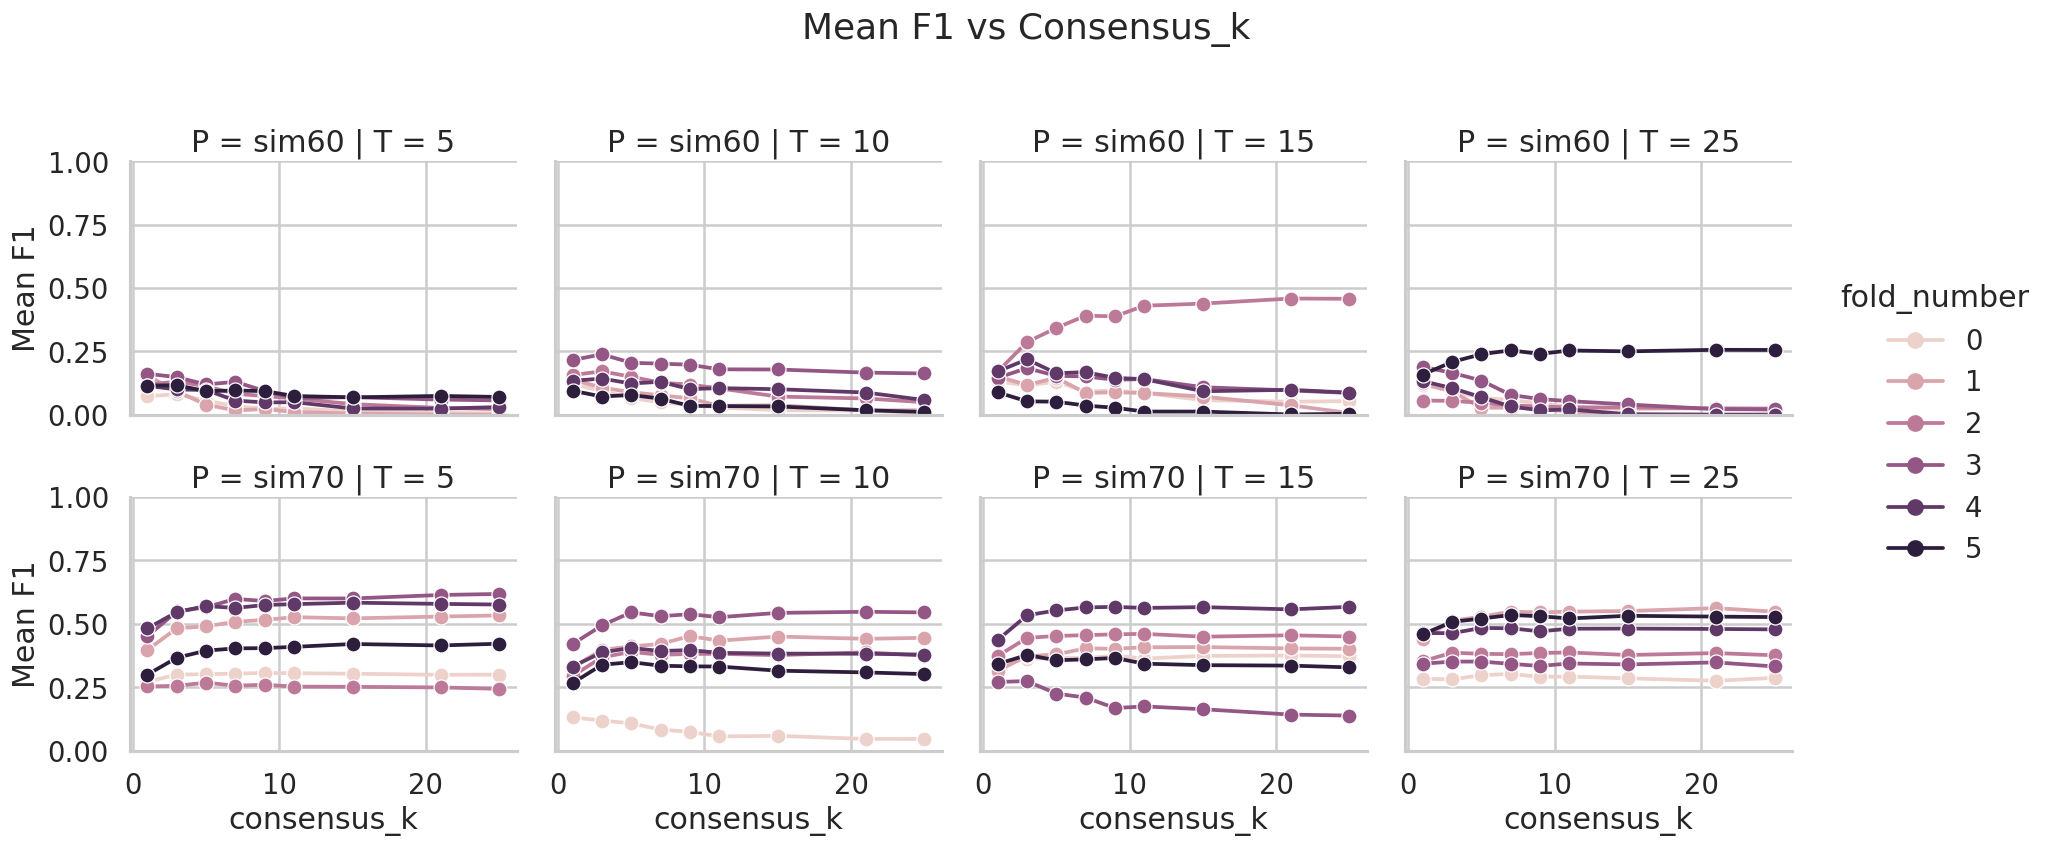

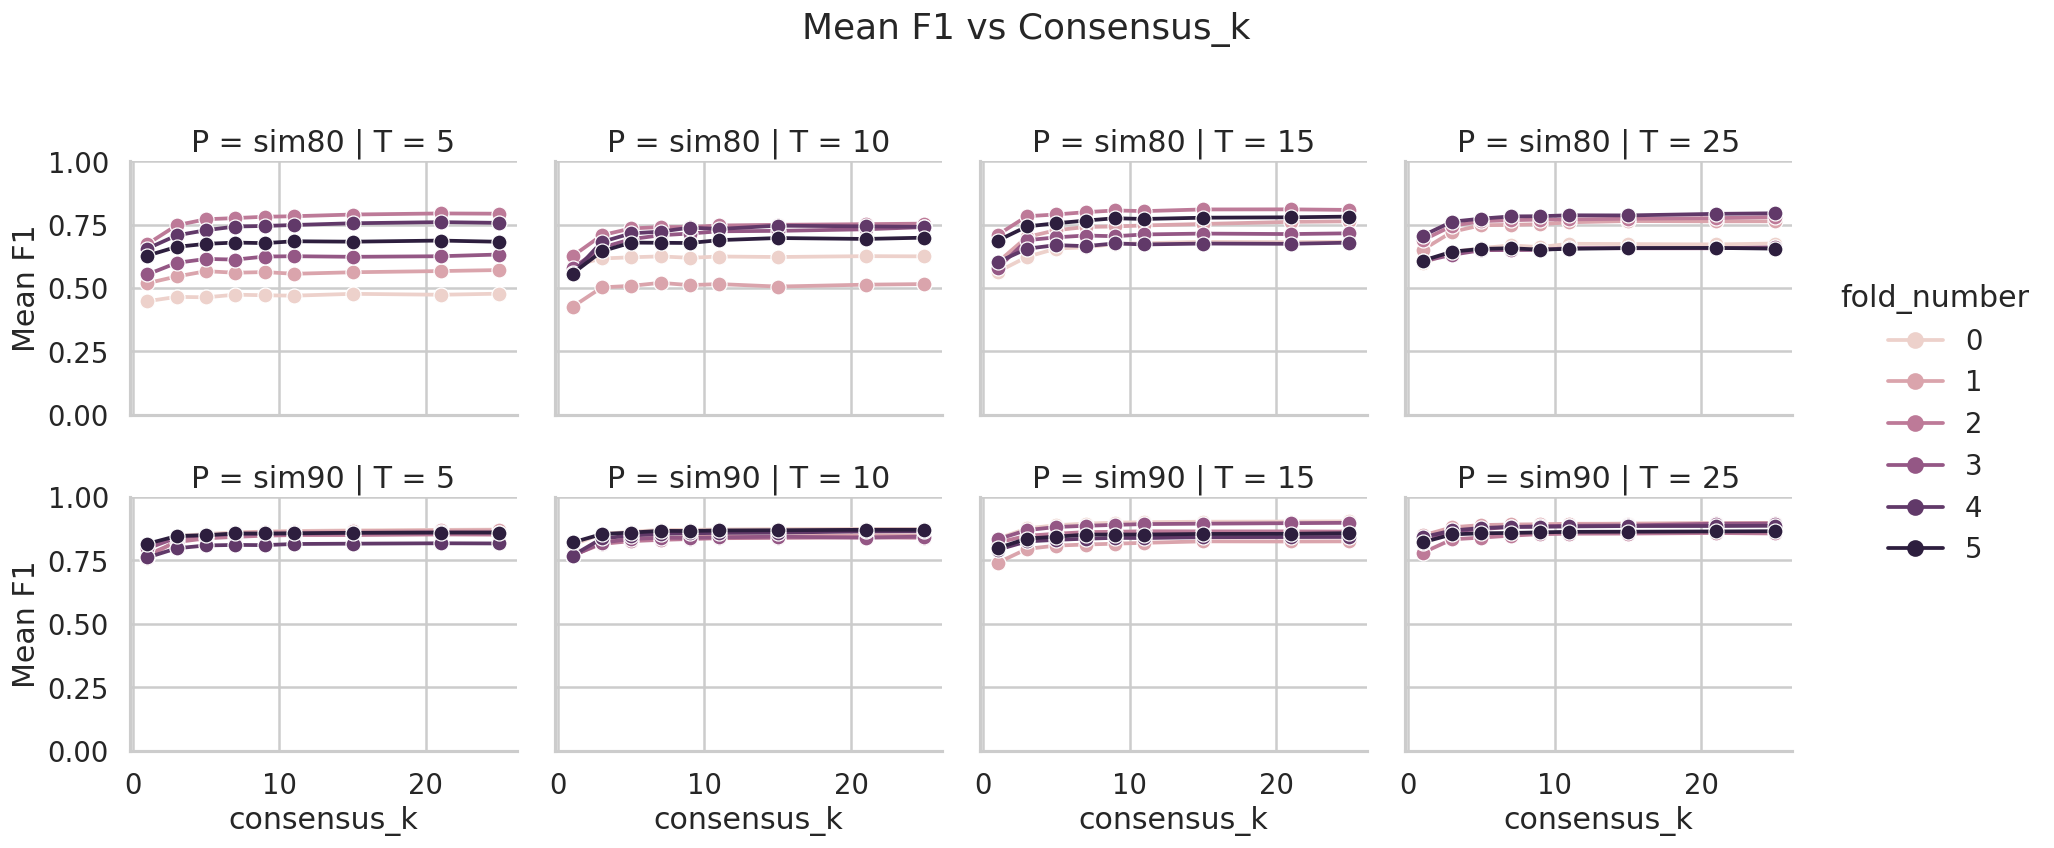

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

timesteps_sorted = sorted(df_.timesteps.unique())
partitions_sorted = sorted(df_.partition.unique())

# dividir partitions en dos bloques de 2
partitions_blocks = [
    partitions_sorted[:2],
    partitions_sorted[2:4]
]

for block in partitions_blocks:

    df_block = df_[df_.partition.isin(block)].sort_values(["consensus_k","partition"])

    g = sns.relplot(
        data=df_block,
        x="consensus_k",
        y="mean_f1",
        hue="fold_number",
        col="timesteps",
        row="partition",
        kind="line",
        marker="o",
        height=3.5,
        aspect=1.1,
        facet_kws=dict(sharex=True, sharey=True)
    )

    g.set_titles(
        row_template="P = {row_name}",
        col_template="T = {col_name}"
    )

    g.set_axis_labels("consensus_k", "Mean F1")
    g.set(ylim=(0, 1))

    g.fig.suptitle("Mean F1 vs Consensus_k", y=1.02)
    g.tight_layout()

    plt.show()


## Load Training/Validation Metrics and Params

This section scans MLflow run directories and builds two tables:
- `metrics_df`: per-run metrics (last value per metric)
- `params_df`: per-run parameters and tags

In [18]:
def read_mlflow_metrics(run_dir: Path):
    metrics_dir = run_dir / 'metrics'
    if not metrics_dir.exists():
        return {}
    out = {}
    for mfile in metrics_dir.iterdir():
        if not mfile.is_file():
            continue
        # MLflow metric file lines: <timestamp> <value> <step>
        try:
            lines = mfile.read_text().strip().splitlines()
            if not lines:
                continue
            last = lines[-1].split()
            if len(last) >= 2:
                out[mfile.name] = float(last[1])
        except Exception:
            continue
    return out

def read_mlflow_meta(run_dir: Path):
    meta_path = run_dir / 'meta.yaml'
    if not meta_path.exists():
        return {}
    try:
        import yaml
        return yaml.safe_load(meta_path.read_text()) or {}
    except Exception:
        return {}

def read_mlflow_params(run_dir: Path):
    params_dir = run_dir / 'params'
    if not params_dir.exists():
        return {}
    out = {}
    for pfile in params_dir.iterdir():
        if not pfile.is_file():
            continue
        try:
            out[pfile.name] = pfile.read_text().strip()
        except Exception:
            continue
    return out

def read_mlflow_tags(run_dir: Path):
    tags_dir = run_dir / 'tags'
    if not tags_dir.exists():
        return {}
    out = {}
    for tfile in tags_dir.iterdir():
        if not tfile.is_file():
            continue
        try:
            out[tfile.name] = tfile.read_text().strip()
        except Exception:
            continue
    return out


In [19]:
metric_rows = []
param_rows = []

for run_dir in iter_run_dirs(MLRUNS_DIR):
    run_id = run_dir.name
    metrics = read_mlflow_metrics(run_dir)
    params = read_mlflow_params(run_dir)
    tags = read_mlflow_tags(run_dir)

    if metrics:
        row = {'run_id': run_id}
        row.update(metrics)
        metric_rows.append(row)

    if params or tags:
        row = {'run_id': run_id}
        # prefix tags to avoid collisions
        row.update(params)
        row.update({f'tag_{k}': v for k, v in tags.items()})
        param_rows.append(row)

metrics_df = pd.DataFrame(metric_rows).set_index('run_id') if metric_rows else pd.DataFrame()
params_df = pd.DataFrame(param_rows).set_index('run_id') if param_rows else pd.DataFrame()

metrics_df.head()


METRICS_OUTPUT_CSV = Path('../logs/metrics_summary_long.csv').resolve()
metrics_df.to_csv(METRICS_OUTPUT_CSV, index=False)

In [20]:
params_df.head()


,fold_number,train_size,test_partition,num_parameters_total,num_workers,main_path,val_path,num_parameters_trainable,partitioned,train_path,batch_size,partition_path,lr,val_size,epochs,val_partition,test_path,train_partition,timesteps,tag_fold_number,tag_mlflow.source.name,tag_mlflow.source.type,tag_mlflow.runName,tag_partition_file,tag_partition_name,tag_mlflow.user,tag_run_name,tag_exp_name,tag_timesteps
run_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3ffcf8cf4b1242b1995692d6dacfba6d,0,234,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,29,15,valid,None,train,25,0,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim80_F0_T25,ArchiveII_partitions_sim80.csv,ArchiveII_partitions_sim80,gkulemeyer,run_PArchiveII_partitions_sim80_F0_T25,Multinomial_simfold_v1,25
7c68311e7b8141ddb5374992f2cc9dbc,2,122,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,11,15,valid,None,train,10,2,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F2_T10,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F2_T10,Multinomial_simfold_v1,10
5535f46843184e3a8d76e33f86076521,4,123,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,9,15,valid,None,train,15,4,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F4_T15,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F4_T15,Multinomial_simfold_v1,15
acd47226550e4db5be542d732e13deeb,3,119,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,14,15,valid,None,train,15,3,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F3_T15,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F3_T15,Multinomial_simfold_v1,15
cff07537ae2f4829ab0ee120c773e3c8,5,514,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,47,15,valid,None,train,15,5,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim90_F5_T15,ArchiveII_partitions_sim90.csv,ArchiveII_partitions_sim90,gkulemeyer,run_PArchiveII_partitions_sim90_F5_T15,Multinomial_simfold_v1,15


In [21]:
params_df["partition"] = params_df["tag_partition_name"].str[-5:]

PARAMS_OUTPUT_CSV = Path('../logs/params_summary_long.csv').resolve()
params_df.to_csv(PARAMS_OUTPUT_CSV, index=False)

## Merge Metrics + Params (Optional)

In [22]:
if not metrics_df.empty and not params_df.empty:
    full_df = metrics_df.join(params_df, how='outer')
    full_df.head()
else:
    full_df = None
    print('metrics_df or params_df is empty')


## Training Metrics Plots

Relational plots and boxplots for training metrics.

In [23]:
import seaborn as sns
sns.set_theme(style='whitegrid')


In [24]:
# Build a plotting table with metrics + params/tags
if metrics_df is None or metrics_df.empty:
    print('metrics_df is empty')
    plot_df = None
else:
    plot_df = metrics_df.copy()
    # Try to get timesteps and fold from params/tags if available
    if 'params_df' in globals() and params_df is not None and not params_df.empty:
        plot_df = plot_df.join(params_df, how='left')
    # Normalize common fields
    if 'timesteps' not in plot_df.columns and 'tag_timesteps' in plot_df.columns:
        plot_df['timesteps'] = plot_df['tag_timesteps']
    if 'fold_number' not in plot_df.columns and 'tag_fold_number' in plot_df.columns:
        plot_df['fold_number'] = plot_df['tag_fold_number']
    plot_df.reset_index(inplace=True) 
plot_df.head() if plot_df is not None else None


,run_id,val_f1,epoch,train_loss,val_loss,fold_number,train_size,test_partition,num_parameters_total,num_workers,main_path,val_path,num_parameters_trainable,partitioned,train_path,batch_size,partition_path,lr,val_size,epochs,val_partition,test_path,train_partition,timesteps,tag_fold_number,tag_mlflow.source.name,tag_mlflow.source.type,tag_mlflow.runName,tag_partition_file,tag_partition_name,tag_mlflow.user,tag_run_name,tag_exp_name,tag_timesteps,partition
0,3ffcf8cf4b1242b1995692d6dacfba6d,0.600933,14.0,0.005206,0.007345,0,234,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,29,15,valid,None,train,25,0,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim80_F0_T25,ArchiveII_partitions_sim80.csv,ArchiveII_partitions_sim80,gkulemeyer,run_PArchiveII_partitions_sim80_F0_T25,Multinomial_simfold_v1,25,sim80
1,7c68311e7b8141ddb5374992f2cc9dbc,0.324069,14.0,0.006400,0.007625,2,122,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,11,15,valid,None,train,10,2,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F2_T10,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F2_T10,Multinomial_simfold_v1,10,sim70
2,5535f46843184e3a8d76e33f86076521,0.340729,14.0,0.008157,0.009279,4,123,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,9,15,valid,None,train,15,4,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F4_T15,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F4_T15,Multinomial_simfold_v1,15,sim70
3,acd47226550e4db5be542d732e13deeb,0.253487,14.0,0.009900,0.010116,3,119,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,14,15,valid,None,train,15,3,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim70_F3_T15,ArchiveII_partitions_sim70.csv,ArchiveII_partitions_sim70,gkulemeyer,run_PArchiveII_partitions_sim70_F3_T15,Multinomial_simfold_v1,15,sim70
4,cff07537ae2f4829ab0ee120c773e3c8,0.710725,14.0,0.001095,0.006886,5,514,test,2721922,2,data/ArchiveII_max_length_128.csv,None,2721922,True,None,4,data/simfolds/simfolds_max128/ArchiveII_partit...,0.001,47,15,valid,None,train,15,5,/home/gkulemeyer/Documents/Repos/sincFoldDD/rn...,LOCAL,run_PArchiveII_partitions_sim90_F5_T15,ArchiveII_partitions_sim90.csv,ArchiveII_partitions_sim90,gkulemeyer,run_PArchiveII_partitions_sim90_F5_T15,Multinomial_simfold_v1,15,sim90


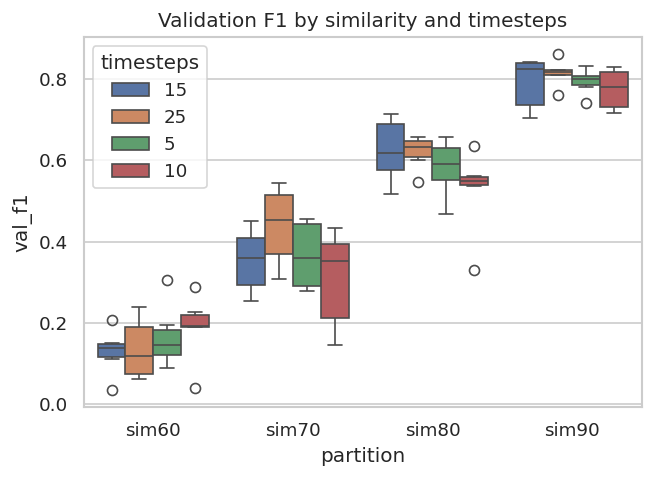

In [25]:
# Boxplot of val_f1 by timesteps
plt.figure(figsize=(6, 4))
sns.boxplot(data=plot_df.sort_values(by="partition"), x='partition', y='val_f1', hue="timesteps")
plt.title('Validation F1 by similarity and timesteps')
plt.show() 

### Rebuild metrics_long_df with epoch only

This version keeps only: `epoch`, `metric`, `value`, `run_id`.

In [36]:
def read_mlflow_metrics_long_epoch_by_order(run_dir: Path):
    metrics_dir = run_dir / 'metrics'
    if not metrics_dir.exists():
        return []
    rows = []
    for mfile in metrics_dir.iterdir():
        if not mfile.is_file():
            continue
        metric_name = mfile.name
        try:
            lines = [l for l in mfile.read_text().strip().splitlines() if l]
            for idx, line in enumerate(lines):
                parts = line.split()
                if len(parts) < 2:
                    continue
                value = float(parts[1])
                rows.append({
                    'metric': metric_name,
                    'value': value,
                    'epoch': idx,
                })
        except Exception:
            continue
    return rows

metrics_long_rows = []
for run_dir in iter_run_dirs(MLRUNS_DIR):
    run_id = run_dir.name
    rows = read_mlflow_metrics_long_epoch_by_order(run_dir)
    if not rows:
        continue
    for r in rows:
        r['run_id'] = run_id
        metrics_long_rows.append(r)

metrics_long_df = pd.DataFrame(metrics_long_rows)[['epoch','metric','value','run_id']]
display(metrics_long_df)
METRICS_LONG_OUTPUT_CSV = Path('../logs/metrics_long_summary_long.csv').resolve()
metrics_long_df.to_csv(METRICS_LONG_OUTPUT_CSV, index=False)

,epoch,metric,value,run_id
0,0,val_f1,0.008647,3ffcf8cf4b1242b1995692d6dacfba6d
1,1,val_f1,0.109933,3ffcf8cf4b1242b1995692d6dacfba6d
2,2,val_f1,0.217462,3ffcf8cf4b1242b1995692d6dacfba6d
3,3,val_f1,0.252176,3ffcf8cf4b1242b1995692d6dacfba6d
4,4,val_f1,0.260306,3ffcf8cf4b1242b1995692d6dacfba6d
...,...,...,...,...
7195,10,val_loss,0.007360,5b565d70b6534d848fc7c8bf8668b112
7196,11,val_loss,0.006913,5b565d70b6534d848fc7c8bf8668b112
7197,12,val_loss,0.007006,5b565d70b6534d848fc7c8bf8668b112
7198,13,val_loss,0.006072,5b565d70b6534d848fc7c8bf8668b112
